<a href="https://colab.research.google.com/github/reshmajayaghosh/ICT_Exit_Exam/blob/main/ICT_Exit_Exam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Bangalore House Dataset Analysis**

# **`Section A Data Wrangling & Exploratory Analysis`**

**Q1** : Load the dataset and perform an initial audit. Report the shape, data types, and count of missing values per column. Then clean the dataset by: (a) dropping rows with missing location or size, and (b) filling missing bath and balcony values with their column medians.

In [610]:
import pandas as pd
import numpy as np

In [611]:
df = pd.read_csv("/content/drive/MyDrive/ICT DSA Python/Data/Bengaluru_House_Data.csv")
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


**`Target Variable : Price`**

In [612]:
df.shape

(13320, 9)

In [613]:
df.size

119880

In [614]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [615]:
df.describe()

,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


Missing Values

In [616]:
df.isna().sum()

,0
area_type,0
availability,0
location,1
size,16
society,5502
total_sqft,0
bath,73
balcony,609
price,0


In [617]:
round(df.isna().mean()*100,2)

,0
area_type,0.00
availability,0.00
location,0.01
size,0.12
society,41.31
total_sqft,0.00
bath,0.55
balcony,4.57
price,0.00


In [618]:
df.dropna(subset=['location','size'], inplace=True)
df.isna().sum()

,0
area_type,0
availability,0
location,0
size,0
society,5499
total_sqft,0
bath,57
balcony,593
price,0


In [619]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
df['bath'] = imputer.fit_transform(df[['bath']])
df['balcony'] = imputer.fit_transform(df[['balcony']])


In [620]:
df['society'] = df['society'].fillna(df['society'].mode()[0])



In [621]:
df.isna().sum()

,0
area_type,0
availability,0
location,0
size,0
society,0
total_sqft,0
bath,0
balcony,0
price,0


In [622]:
df.duplicated().sum()

np.int64(531)

In [623]:
df.drop_duplicates(inplace=True)

**Q2** : The size column contains values like "2 BHK" and "3 Bedroom". Extract only the numeric part and store it as a new integer column called bhk. Similarly, the total_sqft column has some range entries like "1000-1200". Convert these ranges to their average and ensure the entire column is numeric.

In [624]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,GrrvaGr,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,GrrvaGr,1200,2.0,1.0,51.00


In [625]:
df['size'].str.split(" ")[0][0]

'2'

In [626]:
df['bhk'] = df['size'].str.split(" ").str[0]

In [627]:
df['bhk']

,bhk
0,2
1,4
2,3
3,3
4,2
...,...
13314,3
13315,5
13316,4
13317,2


In [628]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12772 entries, 0 to 13318
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     12772 non-null  object 
 1   availability  12772 non-null  object 
 2   location      12772 non-null  object 
 3   size          12772 non-null  object 
 4   society       12772 non-null  object 
 5   total_sqft    12772 non-null  object 
 6   bath          12772 non-null  float64
 7   balcony       12772 non-null  float64
 8   price         12772 non-null  float64
 9   bhk           12772 non-null  object 
dtypes: float64(3), object(7)
memory usage: 1.6+ MB


In [629]:
df['bhk']= df['bhk'].astype('int')

In [630]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,bhk
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07,2
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00,4
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,GrrvaGr,1440,2.0,3.0,62.00,3
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00,3
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,GrrvaGr,1200,2.0,1.0,51.00,2


In [631]:
df.drop(columns =['size'],inplace = True)

In [632]:
df['total_sqft']

,total_sqft
0,1056
1,2600
2,1440
3,1521
4,1200
...,...
13314,1715
13315,3453
13316,3600
13317,1141


In [633]:
for i in (df['total_sqft']):
  if "-" in i:
    print(i.split("-"))
    print((float(i.split("-")[0])+float(i.split("-")[1]))/2)


['2100 ', ' 2850']
2475.0
['3010 ', ' 3410']
3210.0
['2957 ', ' 3450']
3203.5
['3067 ', ' 8156']
5611.5
['1042 ', ' 1105']
1073.5
['1145 ', ' 1340']
1242.5
['1015 ', ' 1540']
1277.5
['1520 ', ' 1740']
1630.0
['1195 ', ' 1440']
1317.5
['1120 ', ' 1145']
1132.5
['4400 ', ' 6640']
5520.0
['3090 ', ' 5002']
4046.0
['4400 ', ' 6800']
5600.0
['1160 ', ' 1195']
1177.5
['4000 ', ' 5249']
4624.5
['1115 ', ' 1130']
1122.5
['520 ', ' 645']
582.5
['1000 ', ' 1285']
1142.5
['3606 ', ' 5091']
4348.5
['650 ', ' 665']
657.5
['633 ', ' 666']
649.5
['1445 ', ' 1455']
1450.0
['884 ', ' 1116']
1000.0
['850 ', ' 1093']
971.5
['1440 ', ' 1884']
1662.0
['547.34 ', ' 827.31']
687.325
['580 ', ' 650']
615.0
['3425 ', ' 3435']
3430.0
['1804 ', ' 2273']
2038.5
['3630 ', ' 3800']
3715.0
['660 ', ' 670']
665.0
['4000 ', ' 5249']
4624.5
['620 ', ' 933']
776.5
['2695 ', ' 2940']
2817.5
['3450 ', ' 3472']
3461.0
['1250 ', ' 1305']
1277.5
['670 ', ' 980']
825.0
['1005.03 ', ' 1252.49']
1128.76
['3630 ', ' 3800']
3715.

AVreage of these numbers

In [634]:
df['total_sqft'] = df['total_sqft'].apply(lambda x: (float(x.split("-")[0])+float(x.split("-")[1]))/2 if "-" in x else x)

In [635]:
df['total_sqft']

,total_sqft
0,1056
1,2600
2,1440
3,1521
4,1200
...,...
13314,1715
13315,3453
13316,3600
13317,1141


In [636]:
df.head()

,area_type,availability,location,society,total_sqft,bath,balcony,price,bhk
0,Super built-up Area,19-Dec,Electronic City Phase II,Coomee,1056,2.0,1.0,39.07,2
1,Plot Area,Ready To Move,Chikka Tirupathi,Theanmp,2600,5.0,3.0,120.00,4
2,Built-up Area,Ready To Move,Uttarahalli,GrrvaGr,1440,2.0,3.0,62.00,3
3,Super built-up Area,Ready To Move,Lingadheeranahalli,Soiewre,1521,3.0,1.0,95.00,3
4,Super built-up Area,Ready To Move,Kothanur,GrrvaGr,1200,2.0,1.0,51.00,2


In [637]:
df['total_sqft']=df['total_sqft'].str.split('Sq').str[0]

In [638]:
df['total_sqft']=df['total_sqft'].str.split('Perch').str[0]

In [639]:
df['total_sqft']=df['total_sqft'].str.split('Acres').str[0]

In [640]:
df['total_sqft']=df['total_sqft'].str.split('Cents').str[0]

In [641]:
df['total_sqft']=df['total_sqft'].str.split('Guntha').str[0]

In [642]:
df['total_sqft']=df['total_sqft'].str.split('G').str[0]

In [643]:
df['total_sqft']=df['total_sqft'].astype('float')

**Q3** Create a new feature price_per_sqft = price x 100000 / total_sqft. Identify and remove outliers where price_per_sqft is beyond mean +/- 3 standard deviations within each location group. Report how many rows were removed and why this location-wise approach is preferred over a global threshold.

In [644]:
df.head()

,area_type,availability,location,society,total_sqft,bath,balcony,price,bhk
0,Super built-up Area,19-Dec,Electronic City Phase II,Coomee,1056.0,2.0,1.0,39.07,2
1,Plot Area,Ready To Move,Chikka Tirupathi,Theanmp,2600.0,5.0,3.0,120.00,4
2,Built-up Area,Ready To Move,Uttarahalli,GrrvaGr,1440.0,2.0,3.0,62.00,3
3,Super built-up Area,Ready To Move,Lingadheeranahalli,Soiewre,1521.0,3.0,1.0,95.00,3
4,Super built-up Area,Ready To Move,Kothanur,GrrvaGr,1200.0,2.0,1.0,51.00,2


In [645]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12772 entries, 0 to 13318
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     12772 non-null  object 
 1   availability  12772 non-null  object 
 2   location      12772 non-null  object 
 3   society       12772 non-null  object 
 4   total_sqft    12580 non-null  float64
 5   bath          12772 non-null  float64
 6   balcony       12772 non-null  float64
 7   price         12772 non-null  float64
 8   bhk           12772 non-null  int64  
dtypes: float64(4), int64(1), object(4)
memory usage: 1.5+ MB


In [646]:
df['price_per_sqft'] = (df['price']* 100000) / df['total_sqft']

Outlier detection

<Axes: >

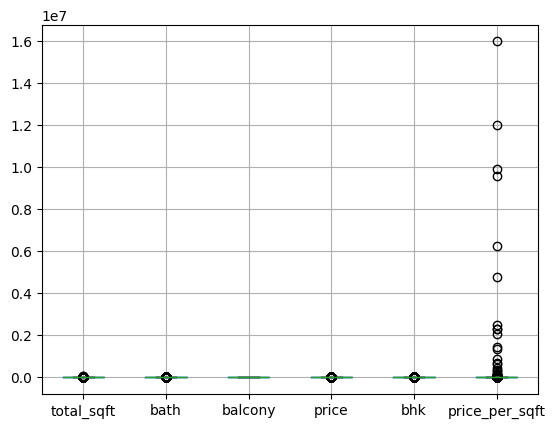

In [647]:
df.boxplot()

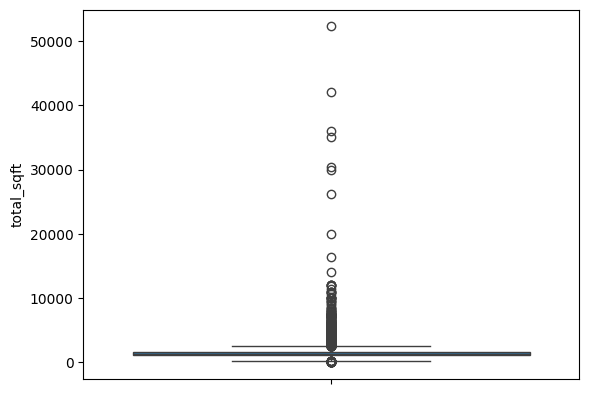

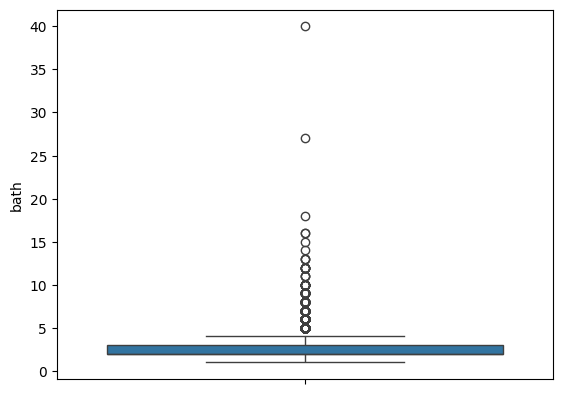

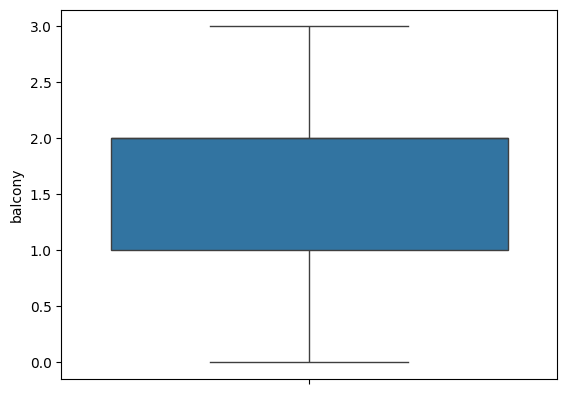

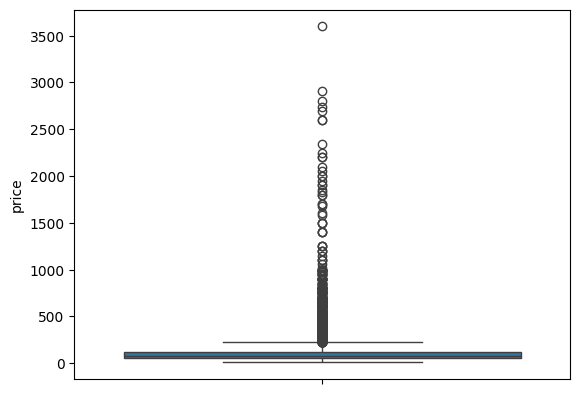

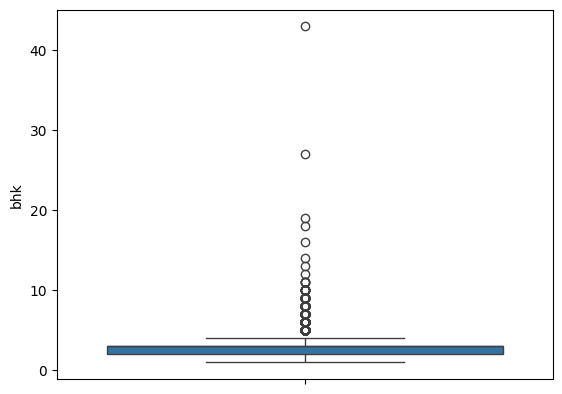

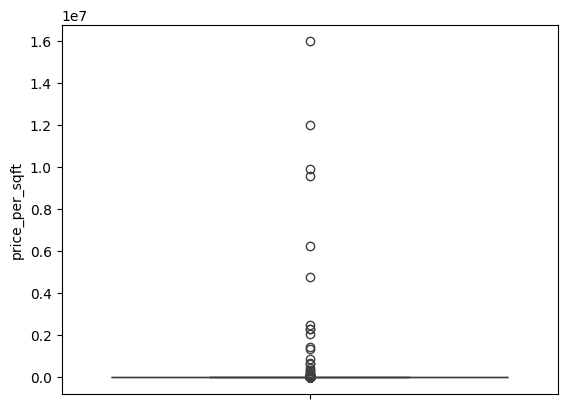

In [648]:
import matplotlib.pyplot as plt
import seaborn as sns

for i in df.select_dtypes("number").columns:
  sns.boxplot(df[i])
  plt.show()

In [649]:
df.describe()

,total_sqft,bath,balcony,price,bhk,price_per_sqft
count,12580.000000,12772.000000,12772.000000,12772.000000,12772.000000,1.258000e+04
mean,1560.743539,2.705528,1.601550,114.348896,2.817961,1.276737e+04
std,1260.846883,1.355682,0.808173,151.515909,1.311955,2.321740e+05
min,1.000000,1.000000,0.000000,8.000000,1.000000,2.678298e+02
25%,1100.000000,2.000000,1.000000,50.000000,2.000000,4.300000e+03
50%,1280.000000,2.000000,2.000000,73.000000,3.000000,5.500000e+03
75%,1683.000000,3.000000,2.000000,121.000000,3.000000,7.451417e+03
max,52272.000000,40.000000,3.000000,3600.000000,43.000000,1.600000e+07


In [650]:
def remove_outliers(df, column):

    def filter(grp):
        mean = grp[column].mean()
        std = grp[column].std()

        lower = mean - (3 * std)
        upper = mean + (3 * std)

        return grp[(grp[column] >= lower) & (grp[column] <= upper)]

    df = df.groupby('location', group_keys=False).apply(filter)

    return df

In [651]:
before = df.shape[0]

In [652]:
df = remove_outliers(df, 'price_per_sqft')

/tmp/ipykernel_2712/127357346.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('location', group_keys=False).apply(filter)


In [653]:
after = df.shape[0]

In [654]:
rows_removed = before - after
rows_removed

814

**Q4** : Produce the following visualizations with proper titles, labels, and color encoding: • Distribution of price_per_sqft (histogram + KDE overlay) • Correlation heatmap of all numeric features • Box plot of price across bhk categories Note: Comment on one key insight observed from each plot.

**Histogram**

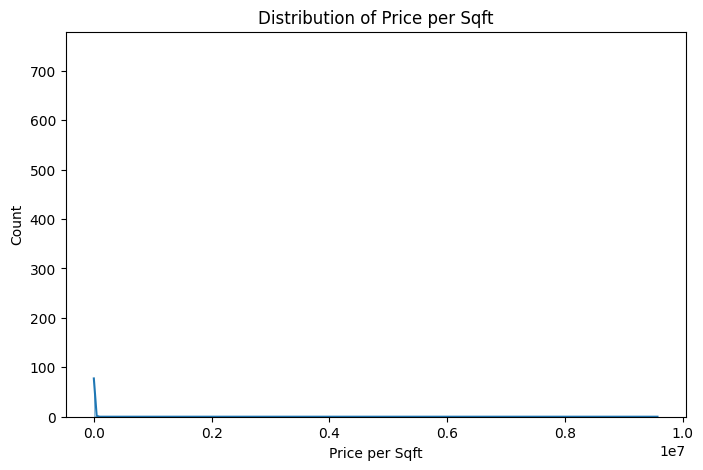

In [655]:
plt.figure(figsize=(8,5))
sns.histplot(df['price_per_sqft'], kde=True)
plt.title("Distribution of Price per Sqft")
plt.xlabel("Price per Sqft")
plt.show()

**Correlation Heatmap**

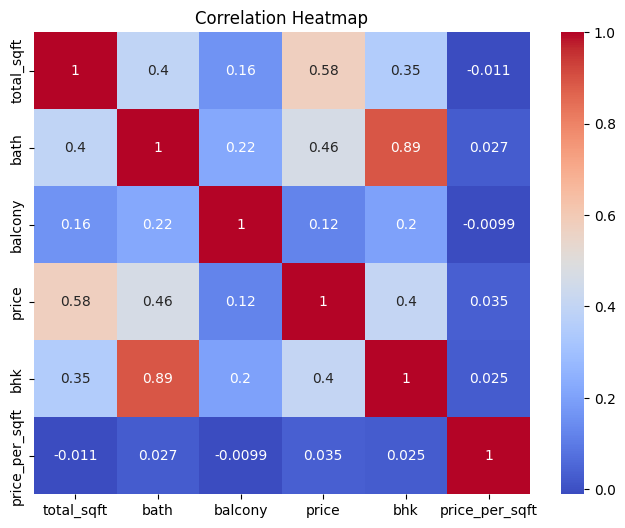

In [656]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

**Boxplot**

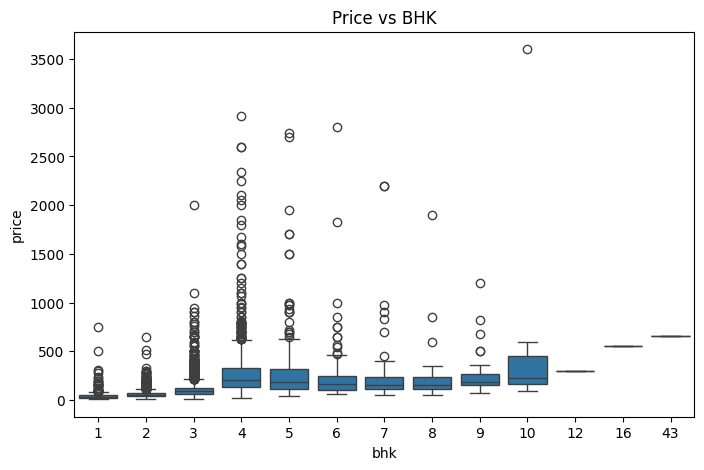

In [657]:
plt.figure(figsize=(8,5))
sns.boxplot(x='bhk', y='price', data=df)
plt.title("Price vs BHK")
plt.show()

**Q5** : Apply one-hot encoding on area_type and label encoding on the top 20 most frequent locations (map all others to "Other"). Apply Min-Max scaling to total_sqft and bath. Briefly justify why you chose these encoding and scaling strategies for each column.

Encoding

In [658]:
df.head()

,area_type,availability,location,society,total_sqft,bath,balcony,price,bhk,price_per_sqft
5610,Super built-up Area,Ready To Move,1st Block BEL Layout,GrrvaGr,1540.0,3.0,2.0,85.0,3,5519.480519
6427,Built-up Area,Ready To Move,1st Block BEL Layout,GrrvaGr,1800.0,5.0,1.0,250.0,4,13888.888889
6675,Plot Area,Ready To Move,1st Block HBR Layout,GrrvaGr,2500.0,6.0,3.0,500.0,5,20000.000000
8470,Super built-up Area,Ready To Move,1st Block HBR Layout,GrrvaGr,600.0,1.0,0.0,45.0,1,7500.000000
12564,Built-up Area,Ready To Move,1st Block HBR Layout,GrrvaGr,3150.0,4.0,2.0,150.0,4,4761.904762


In [659]:
df = pd.get_dummies(df, columns=['area_type'],dtype='int', drop_first=True)

In [660]:
top = df['location'].value_counts().nlargest(20).index
top

Index(['Whitefield', 'Sarjapur  Road', 'Electronic City', 'Kanakpura Road',
       'Thanisandra', 'Yelahanka', 'Marathahalli', 'Raja Rajeshwari Nagar',
       'Uttarahalli', 'Hebbal', 'Hennur Road', 'Bannerghatta Road',
       '7th Phase JP Nagar', 'Electronic City Phase II', 'Rajaji Nagar',
       'Haralur Road', 'Bellandur', 'Electronics City Phase 1', 'KR Puram',
       'Hoodi'],
      dtype='object', name='location')

In [661]:
df['location'] = df['location'].where(df['location'].isin(top), 'Other')

In [662]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['location'] = le.fit_transform(df['location'])

In [663]:
df.head()

,availability,location,society,total_sqft,bath,balcony,price,bhk,price_per_sqft,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area
5610,Ready To Move,13,GrrvaGr,1540.0,3.0,2.0,85.0,3,5519.480519,0,0,1
6427,Ready To Move,13,GrrvaGr,1800.0,5.0,1.0,250.0,4,13888.888889,0,0,0
6675,Ready To Move,13,GrrvaGr,2500.0,6.0,3.0,500.0,5,20000.000000,0,1,0
8470,Ready To Move,13,GrrvaGr,600.0,1.0,0.0,45.0,1,7500.000000,0,0,1
12564,Ready To Move,13,GrrvaGr,3150.0,4.0,2.0,150.0,4,4761.904762,0,0,0


In [664]:
df['availability'].value_counts()

,count
availability,
Ready To Move,9589
18-May,269
18-Dec,260
18-Apr,248
18-Aug,180
...,...
17-Jan,1
16-Jul,1
20-Feb,1


In [665]:
df['society'].value_counts()

,count
society,
GrrvaGr,4891
PrarePa,58
Sryalan,56
GMown E,52
Bhmesy,50
...,...
Saensar,1
Nisisn,1
MDoseim,1


In [666]:
df = df.drop(['availability', 'society'], axis=1)

In [667]:
df.head()

,location,total_sqft,bath,balcony,price,bhk,price_per_sqft,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area
5610,13,1540.0,3.0,2.0,85.0,3,5519.480519,0,0,1
6427,13,1800.0,5.0,1.0,250.0,4,13888.888889,0,0,0
6675,13,2500.0,6.0,3.0,500.0,5,20000.000000,0,1,0
8470,13,600.0,1.0,0.0,45.0,1,7500.000000,0,0,1
12564,13,3150.0,4.0,2.0,150.0,4,4761.904762,0,0,0


In [668]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11958 entries, 5610 to 9683
Data columns (total 10 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   location                        11958 non-null  int64  
 1   total_sqft                      11958 non-null  float64
 2   bath                            11958 non-null  float64
 3   balcony                         11958 non-null  float64
 4   price                           11958 non-null  float64
 5   bhk                             11958 non-null  int64  
 6   price_per_sqft                  11958 non-null  float64
 7   area_type_Carpet  Area          11958 non-null  int64  
 8   area_type_Plot  Area            11958 non-null  int64  
 9   area_type_Super built-up  Area  11958 non-null  int64  
dtypes: float64(5), int64(5)
memory usage: 1.0 MB


**Scaling**

In [669]:
df.describe()

,location,total_sqft,bath,balcony,price,bhk,price_per_sqft,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area
count,11958.000000,11958.000000,11958.000000,11958.000000,11958.000000,11958.000000,1.195800e+04,11958.000000,11958.000000,11958.000000
mean,12.570915,1559.498794,2.667252,1.621007,111.371456,2.775464,7.942302e+03,0.006356,0.139823,0.662987
std,3.560436,1258.241359,1.276160,0.791483,148.769773,1.230421,9.322162e+04,0.079471,0.346818,0.472709
min,0.000000,2.090000,1.000000,0.000000,8.000000,1.000000,2.678298e+02,0.000000,0.000000,0.000000
25%,13.000000,1100.000000,2.000000,1.000000,50.000000,2.000000,4.285714e+03,0.000000,0.000000,0.000000
50%,13.000000,1281.500000,2.000000,2.000000,72.000000,3.000000,5.447616e+03,0.000000,0.000000,1.000000
75%,13.000000,1680.000000,3.000000,2.000000,120.000000,3.000000,7.259008e+03,0.000000,0.000000,1.000000
max,20.000000,52272.000000,40.000000,3.000000,3600.000000,43.000000,9.569378e+06,1.000000,1.000000,1.000000


In [670]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[['total_sqft', 'bath']] = scaler.fit_transform(df[['total_sqft', 'bath']])

One-hot - no order (area_type)


Label encoding - many categories (location)

Scaling - needed for ML models

# **`Section B Supervised Learning`**

**Q6** : Train a Linear Regression model to predict price using all prepared features. Use an 80/20 train-test split (random_state=42). Report RMSE, MAE, and R-squared on the test set. Then train Ridge and Lasso regression models with the same split and compare all three in a results table. Explain why regularisation is beneficial in this context.

In [671]:
df.head()

,location,total_sqft,bath,balcony,price,bhk,price_per_sqft,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area
5610,13,0.029422,0.051282,2.0,85.0,3,5519.480519,0,0,1
6427,13,0.034397,0.102564,1.0,250.0,4,13888.888889,0,0,0
6675,13,0.047789,0.128205,3.0,500.0,5,20000.000000,0,1,0
8470,13,0.011439,0.000000,0.0,45.0,1,7500.000000,0,0,1
12564,13,0.060224,0.076923,2.0,150.0,4,4761.904762,0,0,0


In [672]:
X = df.drop(['price'], axis=1)
y = df['price']


In [673]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Linear Regression**

In [674]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)


In [675]:
np.sqrt(mean_squared_error(y_test, lr_pred))


np.float64(112.0005415809269)

In [676]:
mean_absolute_error(y_test, lr_pred)


41.907277323637736

In [677]:
r2_score(y_test,lr_pred)

0.34369097396498105

Ridge & Lasso

In [678]:
from sklearn.linear_model import Ridge, Lasso

ridge = Ridge()
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)


In [679]:
lasso = Lasso()
lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)

comparing all values

In [680]:
def get_metrics(y_test, y_pred):
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    return rmse, mae, r2

In [681]:
lr_rmse, lr_mae, lr_r2 = get_metrics(y_test, lr_pred)

ridge_rmse, ridge_mae, ridge_r2 = get_metrics(y_test, ridge_pred)

lasso_rmse, lasso_mae, lasso_r2 = get_metrics(y_test, lasso_pred)

In [682]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge', 'Lasso'],
    'RMSE': [lr_rmse, ridge_rmse, lasso_rmse],
    'MAE': [lr_mae, ridge_mae, lasso_mae],
    'R2 Score': [lr_r2, ridge_r2, lasso_r2]
})

print(results.round(3))

               Model     RMSE     MAE  R2 Score
0  Linear Regression  112.001  41.907     0.344
1              Ridge  108.847  42.670     0.380
2              Lasso  111.341  49.886     0.351


Regularisatio helps prevent overfitting by adding a penalty to large coefficients.

- Lasso penalize by sum of absolute values coffients
- Ridge penealize by sum of squares of coffients

**Q7** :Create a binary classification target: high_value = 1 if price >= 100 lakhs, else 0. Train a Logistic Regression and a Naive Bayes classifier on this target. Report accuracy, precision, recall, and F1-score for both. Plot the confusion matrix for the better-performing model.

In [683]:
df['high_value'] = df['price'].apply(lambda x: 1 if x >= 100 else 0)


In [684]:

X = df.drop(['price', 'high_value'], axis=1)
y = df['high_value']

In [685]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Logistic**

In [686]:
from sklearn.linear_model import LogisticRegression

log = LogisticRegression()
log.fit(X_train, y_train)

log_pred = log.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [687]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print(accuracy_score(y_test, log_pred))
print(precision_score(y_test, log_pred))
print(recall_score(y_test, log_pred))
print(f1_score(y_test, log_pred))

0.7905518394648829
0.7803347280334728
0.4850455136540962
0.5982357658380112


Naive Bayes

In [688]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)

nb_pred = nb.predict(X_test)

In [689]:
print(accuracy_score(y_test, nb_pred))
print(precision_score(y_test, nb_pred))
print(recall_score(y_test, nb_pred))
print(f1_score(y_test, nb_pred))

0.6785117056856187
0.5
0.0013003901170351106
0.0025940337224383916


Confusion Matrix for Logistic Regression

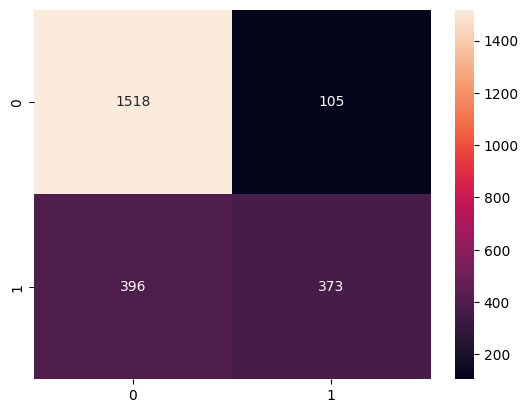

In [690]:
cm = confusion_matrix(y_test, log_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

**Q8** Train a Random Forest classifier on the same binary target. Use GridSearchCV with 5-fold cross-validation to tune n_estimators (50, 100, 200) and max_depth (None, 5, 10). Report the best parameters, best cross-val score, and test set metrics. Plot feature importances as a horizontal bar chart.

**Random Forest Classifier**

In [691]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

random = RandomForestClassifier()
random.fit(X_train, y_train)

random_pred = random.predict(X_test)

In [692]:
print(accuracy_score(y_test, random_pred))
print(precision_score(y_test, random_pred))
print(recall_score(y_test, random_pred))
print(f1_score(y_test, random_pred))

0.9899665551839465
0.9894875164257556
0.9791937581274383
0.984313725490196


In [693]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10]
}

rf = RandomForestClassifier()

grid = GridSearchCV(rf, param_grid, cv=5)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Params: {'max_depth': None, 'n_estimators': 200}
Best Score: 0.9901734871289822


**Feature Importance**

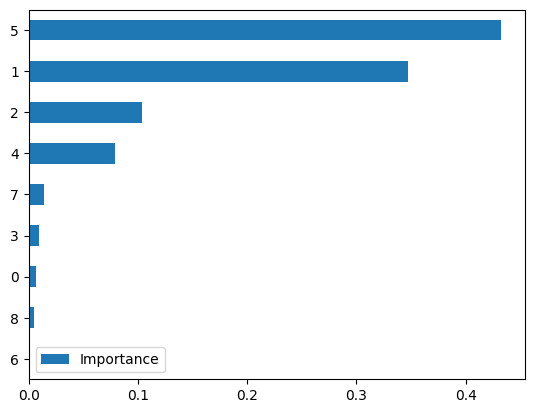

In [694]:
importances = grid.best_estimator_.feature_importances_

feat_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feat_df = feat_df.sort_values(by='Importance')

feat_df.plot(kind='barh')
plt.show()

# **`Section C Unsupervised Learning & Dimensionality Reduction`**

**Q9** Apply K-Means clustering on total_sqft, bath, and price_per_sqft. Use the elbow method (k = 2 to 10) to choose the optimal number of clusters. Visualise the clusters using a 2D scatter plot and briefly describe the property profile of each cluster.

In [695]:
df.head()

,location,total_sqft,bath,balcony,price,bhk,price_per_sqft,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area,high_value
5610,13,0.029422,0.051282,2.0,85.0,3,5519.480519,0,0,1,0
6427,13,0.034397,0.102564,1.0,250.0,4,13888.888889,0,0,0,1
6675,13,0.047789,0.128205,3.0,500.0,5,20000.000000,0,1,0,1
8470,13,0.011439,0.000000,0.0,45.0,1,7500.000000,0,0,1,0
12564,13,0.060224,0.076923,2.0,150.0,4,4761.904762,0,0,0,1


In [696]:
from sklearn.cluster import KMeans

features = df[['total_sqft', 'bath', 'price_per_sqft']]


**Elboe method**

In [697]:
wcss = []
for i in range(2, 11):
    km = KMeans(n_clusters=i,init= 'k-means++',random_state=42)
    km.fit(features)
    wcss.append(km.inertia_)



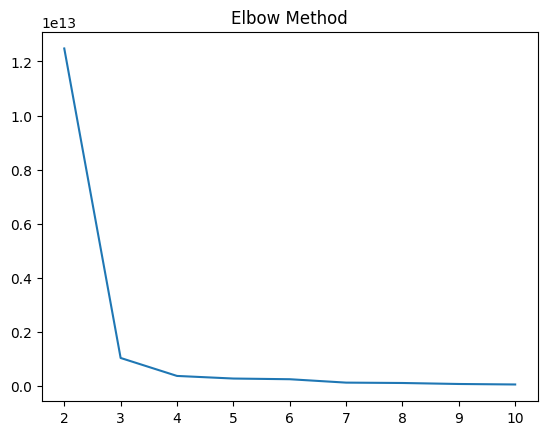

In [698]:
plt.plot(range(2,11), wcss)
plt.title("Elbow Method")
plt.show()

K= 3

Clustering

In [699]:
kmeans = KMeans(n_clusters=3,init= 'k-means++',random_state=42)
y_kmeans=kmeans.fit_predict(features)
y_kmeans


array([0, 0, 0, ..., 0, 0, 0], dtype=int32)

In [700]:
df['cluster'] = y_kmeans

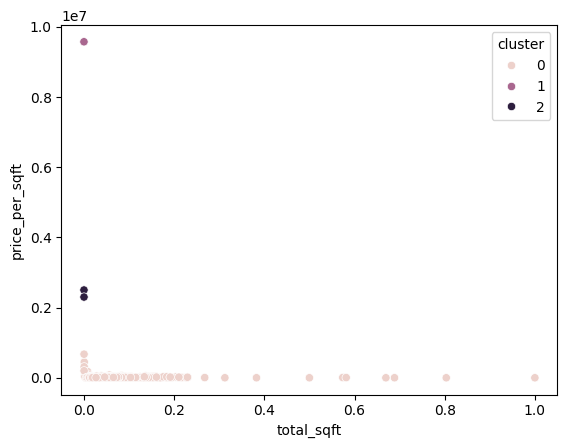

In [701]:

sns.scatterplot(x='total_sqft', y='price_per_sqft', hue='cluster', data=df)
plt.show()

Cluster 0 - low price homes

**Q10**: Apply PCA to the full feature set (post-encoding and scaling). Plot the explained variance ratio for the top 10 components. Retrain your best classifier from Section B using only the top 5 principal components and compare its performance to the original. Comment on the trade-off between dimensionality reduction and model accuracy.

In [702]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(X)


PCA()

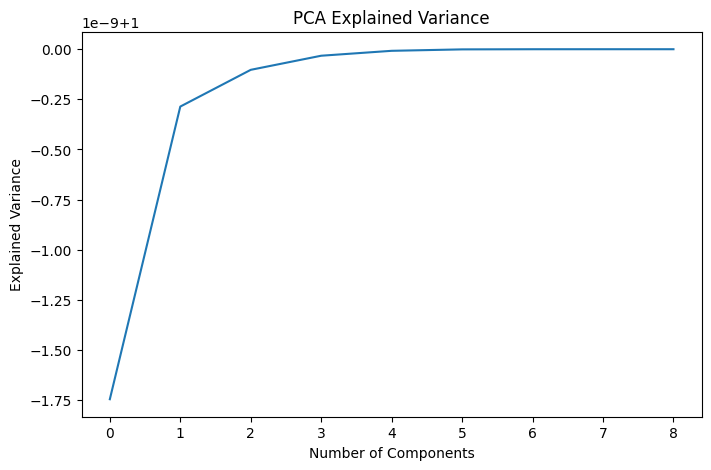

In [703]:

plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of Components")
plt.ylabel("Explained Variance")
plt.title("PCA Explained Variance")
plt.show()

**Reduce to 5 components**

In [704]:
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)


In [705]:

rf = RandomForestClassifier()
rf.fit(X_train, y_train)
pred = rf.predict(X_test)


In [706]:

accuracy_score(y_test, pred)

0.9339464882943144

**saving the model - Use the GridSearch Random Forest**

In [707]:
import pickle

pickle.dump(grid.best_estimator_, open("/content/drive/MyDrive/ICT DSA Python/Data/model.pkl",'wb'))